# Classification experiments

In [6]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [8]:
def evaluate_predictions(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
    print("MCC      :", matthews_corrcoef(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

### Load data

In [ ]:
train_data = pd.read_pickle(DATA/'ml_datasets2/L2_TRAIN.pkl')

In [19]:
features = train_data.iloc[:, :10]
target = train_data[['source']]

**SPLIT**

In [36]:
X = features.copy()
Y = target.copy()

In [37]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

In [22]:
print(X_train.shape)
print(X_val.shape)

(4623, 10)
(1156, 10)


### Baseline RF 

In [23]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

### 1. All source lables

In [24]:
Y_train_1 = Y_train['source']
Y_val_1 = Y_val['source']

le_1 = LabelEncoder()
Y_train_source = le_1.fit_transform(Y_train_1)
Y_val_source = le_1.transform(Y_val_1)

In [25]:
base_rf.fit(X_train, Y_train_source)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

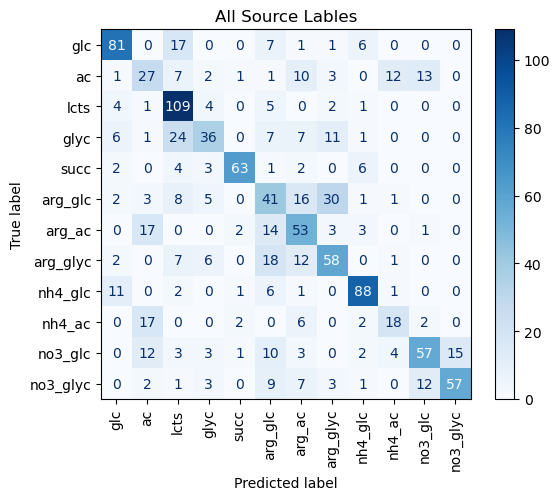

In [27]:
Y_pred_val = base_rf.predict(X_val)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_glyc']

cm = confusion_matrix(le_1.inverse_transform(Y_val_source), 
                      le_1.inverse_transform(Y_pred_val),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("All Source Lables")
plt.show()

In [28]:
evaluate_predictions(
    Y_val_source,
    Y_pred_val,
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.5951557093425606
Precision: 0.6014927156256655
Recall   : 0.5757783599568497
F1       : 0.5814468534859022
MCC      : 0.5573095595266698

Classification report:
              precision    recall  f1-score   support

           0       0.34      0.35      0.34        77
           1       0.45      0.57      0.50        93
           2       0.34      0.38      0.36       107
           3       0.52      0.56      0.54       104
           4       0.74      0.72      0.73       113
           5       0.58      0.39      0.46        93
           6       0.60      0.87      0.71       126
           7       0.49      0.38      0.43        47
           8       0.79      0.80      0.80       110
           9       0.67      0.52      0.58       110
          10       0.79      0.60      0.68        95
          11       0.90      0.78      0.83        81

    accuracy                           0.60      1156
   macro avg       0.60   

In [29]:
print(classification_report(
    Y_val_source,
    Y_pred_val,
    target_names=le_1.classes_
))

              precision    recall  f1-score   support

          ac       0.34      0.35      0.34        77
      arg_ac       0.45      0.57      0.50        93
     arg_glc       0.34      0.38      0.36       107
    arg_glyc       0.52      0.56      0.54       104
         glc       0.74      0.72      0.73       113
        glyc       0.58      0.39      0.46        93
        lcts       0.60      0.87      0.71       126
      nh4_ac       0.49      0.38      0.43        47
     nh4_glc       0.79      0.80      0.80       110
     no3_glc       0.67      0.52      0.58       110
    no3_glyc       0.79      0.60      0.68        95
        succ       0.90      0.78      0.83        81

    accuracy                           0.60      1156
   macro avg       0.60      0.58      0.58      1156
weighted avg       0.61      0.60      0.59      1156



### 2. Limiting nutrient

In [30]:
Y_train_2 = Y_train['source'].str.split('_').str[0]
Y_val_2 = Y_val['source'].str.split('_').str[0]

le_2 = LabelEncoder()

Y_train_source2 = le_2.fit_transform(Y_train_2)
Y_val_source2 = le_2.transform(Y_val_2)

In [31]:
base_rf.fit(X_train, Y_train_source2)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

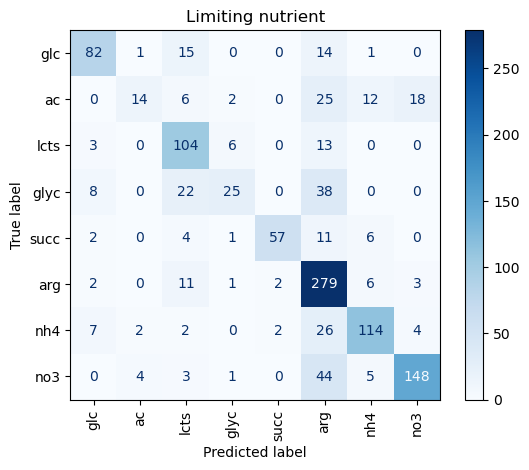

In [32]:
Y_pred_val2 = base_rf.predict(X_val)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(le_2.inverse_transform(Y_val_source2), 
                      le_2.inverse_transform(Y_pred_val2),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Limiting nutrient")
plt.show()

In [33]:
evaluate_predictions(
    Y_val_source2,
    Y_pred_val2,
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.7119377162629758
Precision: 0.7467389207806557
Recall   : 0.6339035823903008
F1       : 0.6527978728069723
MCC      : 0.6595158958537108

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.18      0.29        77
           1       0.62      0.92      0.74       304
           2       0.79      0.73      0.76       113
           3       0.69      0.27      0.39        93
           4       0.62      0.83      0.71       126
           5       0.79      0.73      0.76       157
           6       0.86      0.72      0.78       205
           7       0.93      0.70      0.80        81

    accuracy                           0.71      1156
   macro avg       0.75      0.63      0.65      1156
weighted avg       0.73      0.71      0.69      1156



In [34]:
print(classification_report(
    Y_val_source2,
    Y_pred_val2,
    target_names=le_2.classes_
))

              precision    recall  f1-score   support

          ac       0.67      0.18      0.29        77
         arg       0.62      0.92      0.74       304
         glc       0.79      0.73      0.76       113
        glyc       0.69      0.27      0.39        93
        lcts       0.62      0.83      0.71       126
         nh4       0.79      0.73      0.76       157
         no3       0.86      0.72      0.78       205
        succ       0.93      0.70      0.80        81

    accuracy                           0.71      1156
   macro avg       0.75      0.63      0.65      1156
weighted avg       0.73      0.71      0.69      1156



### 3. Binary

In [14]:
Y_train_3 = Y_train['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})
Y_val_3 = Y_val['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})

le3 = LabelEncoder()
Y_train_bin = le3.fit_transform(Y_train_3)
Y_val_bin = le3.transform(Y_val_3)

In [39]:
base_rf.fit(X_train, Y_train_bin)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

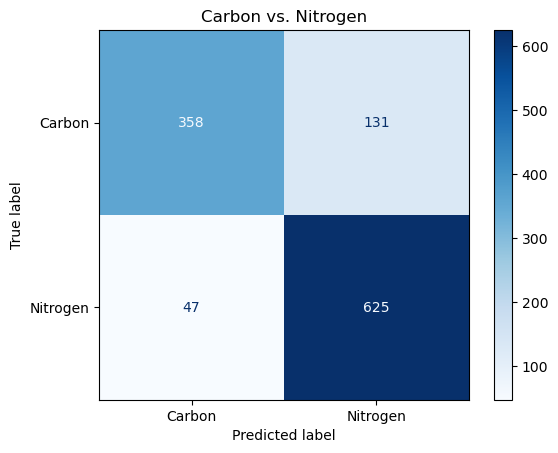

In [19]:
Y_pred_val_3 = base_rf.predict(X_val)

cm = confusion_matrix(Y_val_bin, Y_pred_val_3)
disp = ConfusionMatrixDisplay(cm, display_labels=le3.classes_)

disp.plot(cmap='Blues')
plt.title("Carbon vs. Nitrogen")
plt.show()

In [20]:
evaluate_predictions(
    Y_val_bin,
    Y_pred_val_3,
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.8466838931955211
Precision: 0.8553350970017637
Recall   : 0.8310829316389132
F1       : 0.8381224973210761
MCC      : 0.6859894623958637

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       489
           1       0.83      0.93      0.88       672

    accuracy                           0.85      1161
   macro avg       0.86      0.83      0.84      1161
weighted avg       0.85      0.85      0.84      1161



In [131]:
accuracy = accuracy_score(Y_val_bin, Y_pred_val_3)
precision = precision_score(Y_val_bin, Y_pred_val_3)
recall = recall_score(Y_val_bin, Y_pred_val_3)
f1 = f1_score(Y_val_bin, Y_pred_val_3)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.847
Precision: 0.827
Recall:    0.930
F1-score:  0.875


### 4. Carbon and Nitrogen separate

In [15]:
X_train_c = X_train[Y_train_3 == 'Carbon']
X_val_c = X_val[Y_val_3 == 'Carbon']

Y_train_c = Y_train[Y_train_3 == 'Carbon']
Y_val_c = Y_val[Y_val_3 == 'Carbon']

#######################################################
X_train_n = X_train[Y_train_3 == 'Nitrogen']
X_val_n = X_val[Y_val_3 == 'Nitrogen']

Y_train_n = Y_train[Y_train_3 == 'Nitrogen']
Y_val_n = Y_val[Y_val_3 == 'Nitrogen']

In [16]:
Y_train_c = Y_train_c['source']
Y_val_c = Y_val_c['source']

le_c = LabelEncoder()

Y_train_enc_c = le_c.fit_transform(Y_train_c)
Y_val_enc_c = le_c.fit_transform(Y_val_c)

#########################################

le_n = LabelEncoder()

Y_train_n = Y_train_n['source']
Y_val_n = Y_val_n['source']
# Y_train_n = Y_train_n['source'].str.split('_').str[0]
# Y_val_n = Y_val_n['source'].str.split('_').str[0]

Y_train_enc_n = le_n.fit_transform(Y_train_n)
Y_val_enc_n = le_n.fit_transform(Y_val_n)

**CARBON**

In [54]:
base_rf.fit(X_train_c, Y_train_enc_c)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

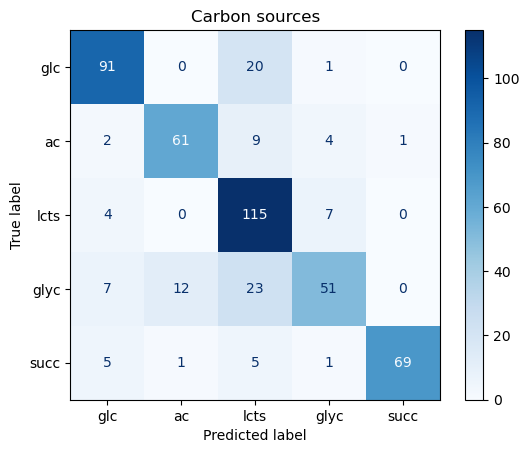

In [24]:
Y_pred_val_c = base_rf.predict(X_val_c)

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ']

cm = confusion_matrix(le_c.inverse_transform(Y_val_enc_c), 
                      le_c.inverse_transform(Y_pred_val_c),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues')
plt.title("Carbon sources")
plt.show()

In [27]:
evaluate_predictions(
    Y_val_c,
    le_c.inverse_transform(Y_pred_val_c),
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.7914110429447853
Precision: 0.8220761293045002
Recall   : 0.7835290307064501
F1       : 0.7933754651199602
MCC      : 0.7407897744286884

Classification report:
              precision    recall  f1-score   support

          ac       0.82      0.79      0.81        77
         glc       0.83      0.81      0.82       112
        glyc       0.80      0.55      0.65        93
        lcts       0.67      0.91      0.77       126
        succ       0.99      0.85      0.91        81

    accuracy                           0.79       489
   macro avg       0.82      0.78      0.79       489
weighted avg       0.81      0.79      0.79       489



In [137]:
print(classification_report(
    Y_val_enc_c,
    Y_pred_val_c,
    target_names=le_c.classes_
))

              precision    recall  f1-score   support

          ac       0.82      0.79      0.81        77
         glc       0.83      0.81      0.82       112
        glyc       0.80      0.55      0.65        93
        lcts       0.67      0.91      0.77       126
        succ       0.99      0.85      0.91        81

    accuracy                           0.79       489
   macro avg       0.82      0.78      0.79       489
weighted avg       0.81      0.79      0.79       489



**NITROGEN**

In [17]:
base_rf.fit(X_train_n, Y_train_enc_n)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

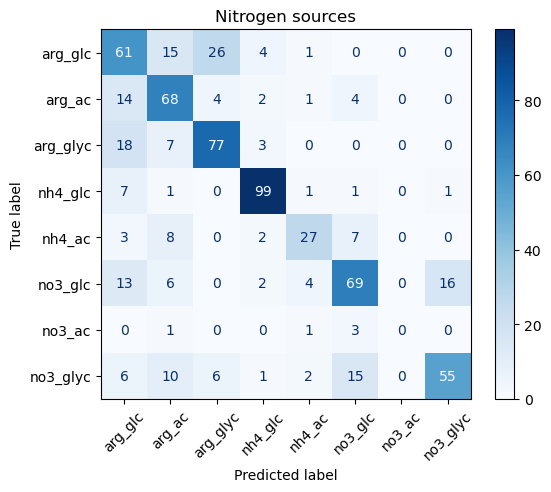

In [19]:
Y_pred_val_n = base_rf.predict(X_val_n)

env_order = ['arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

cm = confusion_matrix(le_n.inverse_transform(Y_val_enc_n), 
                      le_n.inverse_transform(Y_pred_val_n),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Nitrogen sources")
plt.show()

In [153]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

      arg_ac       0.59      0.73      0.65        93
     arg_glc       0.50      0.57      0.53       107
    arg_glyc       0.68      0.73      0.71       105
      nh4_ac       0.73      0.57      0.64        47
     nh4_glc       0.88      0.90      0.89       110
      no3_ac       0.00      0.00      0.00         5
     no3_glc       0.70      0.63      0.66       110
    no3_glyc       0.76      0.58      0.66        95

    accuracy                           0.68       672
   macro avg       0.60      0.59      0.59       672
weighted avg       0.68      0.68      0.68       672



/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [20]:
evaluate_predictions(
    Y_val_n,
    le_n.inverse_transform(Y_pred_val_n),
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.6785714285714286
Precision: 0.6042896670042306
Recall   : 0.5894122209720433
F1       : 0.5924512561262465
MCC      : 0.6232856065361272

Classification report:
              precision    recall  f1-score   support

      arg_ac       0.59      0.73      0.65        93
     arg_glc       0.50      0.57      0.53       107
    arg_glyc       0.68      0.73      0.71       105
      nh4_ac       0.73      0.57      0.64        47
     nh4_glc       0.88      0.90      0.89       110
      no3_ac       0.00      0.00      0.00         5
     no3_glc       0.70      0.63      0.66       110
    no3_glyc       0.76      0.58      0.66        95

    accuracy                           0.68       672
   macro avg       0.60      0.59      0.59       672
weighted avg       0.68      0.68      0.68       672



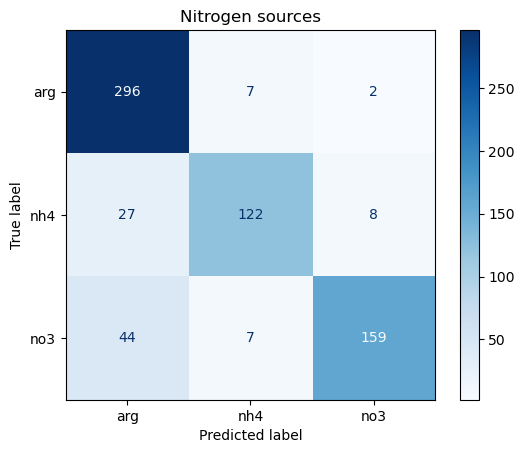

In [29]:
Y_pred_val_n = base_rf.predict(X_val_n)

env_order = ['arg', 'nh4', 'no3']

cm = confusion_matrix(le_n.inverse_transform(Y_val_enc_n), 
                      le_n.inverse_transform(Y_pred_val_n),
                      labels=env_order)

disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='Blues')
plt.title("Nitrogen sources")
plt.show()

In [30]:
evaluate_predictions(
    Y_val_n,
    le_n.inverse_transform(Y_pred_val_n),
    "RF pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.8586309523809523
Precision: 0.8814755784776868
Recall   : 0.8349015747052712
F1       : 0.850922339332652
MCC      : 0.7830156281588991

Classification report:
              precision    recall  f1-score   support

         arg       0.81      0.97      0.88       305
         nh4       0.90      0.78      0.83       157
         no3       0.94      0.76      0.84       210

    accuracy                           0.86       672
   macro avg       0.88      0.83      0.85       672
weighted avg       0.87      0.86      0.86       672



In [ ]:
print(classification_report(
    Y_val_enc_n,
    Y_pred_val_n,
    target_names=le_n.classes_
))

              precision    recall  f1-score   support

         arg       0.81      0.97      0.88       305
         nh4       0.90      0.78      0.83       157
         no3       0.94      0.76      0.84       210

    accuracy                           0.86       672
   macro avg       0.88      0.83      0.85       672
weighted avg       0.87      0.86      0.86       672



# TEST

In [36]:
test_data = pd.read_pickle('/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/L2_IID_TEST.pkl')

features_test = test_data.iloc[:, :10]

# target = train_data[['source']].copy()
test_data['source'] = test_data['source'].str.split('_').str[0] #less specific nitrogen source
test_data['source_type'] = test_data['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'Nitrogen', False: 'Carbon'})

In [58]:
y_test_type = le3.transform(test_data["source_type"])
y_test_source = le_2.transform(test_data["source"])

X_test = features_test

In [38]:
carbon_mask_test = test_data["source_type"] == "Carbon"
nitrogen_mask_test = test_data["source_type"] == "Nitrogen"

X_c_test = X_test[carbon_mask_test.values]
X_n_test = X_test[nitrogen_mask_test.values]

y_c_test = le_c.transform(
    test_data.loc[carbon_mask_test, "source"]
)

y_n_test = le_n.transform(
    test_data.loc[nitrogen_mask_test, "source"]
)

In [62]:
y_test_pred = base_rf.predict(X_test)


evaluate_predictions(
    le_2.inverse_transform(y_test_pred),
    le_2.inverse_transform(y_test_source),
    "RF baseline"
)


=== RF baseline ===
Accuracy : 0.696969696969697
Precision: 0.6272187723942779
Recall   : 0.6929013073024928
F1       : 0.6299491610347323
MCC      : 0.6412608034129558

Classification report:
              precision    recall  f1-score   support

          ac       0.16      0.43      0.23        35
         arg       0.89      0.65      0.75       522
         glc       0.70      0.65      0.68       152
        glyc       0.25      0.74      0.37        39
        lcts       0.83      0.58      0.68       224
         nh4       0.68      0.78      0.73       170
         no3       0.69      0.87      0.77       211
        succ       0.81      0.84      0.83        99

    accuracy                           0.70      1452
   macro avg       0.63      0.69      0.63      1452
weighted avg       0.77      0.70      0.72      1452



In [55]:
y_test_c_pred = base_rf.predict(X_c_test)


evaluate_predictions(
    le_c.inverse_transform(y_c_test),
    le_c.inverse_transform(y_test_c_pred),
    "RF baseline: Carbon"
)


=== RF baseline: Carbon ===
Accuracy : 0.8022875816993464
Precision: 0.8318336445370136
Recall   : 0.7966154872419502
F1       : 0.8072347563950192
MCC      : 0.7537844782246671

Classification report:
              precision    recall  f1-score   support

          ac       0.86      0.78      0.82        96
         glc       0.85      0.79      0.82       141
        glyc       0.82      0.62      0.71       116
        lcts       0.67      0.90      0.77       157
        succ       0.96      0.88      0.92       102

    accuracy                           0.80       612
   macro avg       0.83      0.80      0.81       612
weighted avg       0.82      0.80      0.80       612



In [ ]:
y_test_n_pred = base_rf.predict(X_n_test)


evaluate_predictions(
    le_c.inverse_transform(y_c_test),
    le_c.inverse_transform(y_test_c_pred),
    "RF baseline: Carbon"
)